# The Cache Hierarchy of an AMD Ryzen AI 9 HX 370

Memory is presented to your program as one flat, uniform array of bytes. It is not one, and it is
not uniform. Underneath the abstraction is a hierarchy whose fastest and slowest levels differ by a
factor of **59,000** in latency on this machine. Nothing in the C or Python type system tells you
which level you are touching. Your access pattern decides it.

This notebook is a measured description of the memory system of one specific computer: an **AMD
Ryzen AI 9 HX 370** (Zen 5, "Strix Point"), 12 cores / 24 threads, LPDDR5X, one NVMe SSD, running
Linux. Every number below was produced by the six benchmark programs in this directory; every plot
is generated from the `.csv` files they emit. Nothing is quoted from a specification sheet.

## What this machine turns out to be

| | measured | §|
|---|---|---|
| Cache line | **64 bytes** at every level | 6 |
| Latency, L1 → DRAM | **4 → 530 cycles** (0.78 ns → 104 ns) | 3 |
| Hardware prefetching | worth up to **77x** when the access pattern is predictable | 4 |
| Address translation | **2.4x** on an L3-resident random pattern; huge pages remove it | 5 |
| Line utilization | **8x** swing between stride-8 and stride-64 access | 6 |
| DRAM bandwidth | **38.5 GB/s** from one core — and 38.8 GB/s from twelve | 7 |
| Array dimensions | a power-of-two row length costs up to **32x** on column traversal | 8 |
| Sharing one cache line | **18 ns** between SMT siblings, ~20 ns within a core complex, **~167 ns** across | 9 |
| Below DRAM | NVMe SSD at **45.8 µs** — 59,000 L1 hits | 10 |

Every row of that table is a factor your source code does not mention and your compiler will not
choose for you. Together they are worth more than most algorithmic improvements you will ever make,
which is the argument for spending a lecture on hardware you did not design and cannot change.

## How to read this notebook

Sections 3 through 5 characterize **one thread touching memory**: how long an access takes, what the
prefetcher can hide, what address translation costs. Sections 6 through 8 are about **layout and
access order** — the decisions you actually control in source code. Sections 9 and 10 add the other
threads and the storage tier. Section 11 is the checklist; section 12 is how to re-run all of it.

The benchmarks are worth reading alongside the results: each `.c` file opens with a comment on the
measurement traps it had to avoid, which are as instructive as the numbers.

In [1]:
import csv, subprocess, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

HERE = Path.cwd()

# The .csv files in this directory are the measurements this notebook plots.
# Set this True to re-run every benchmark from scratch (~12 minutes, and it
# needs an otherwise idle machine -- all of these measure a shared resource).
RUN_BENCHMARKS = False
if RUN_BENCHMARKS:
    subprocess.run(["make", "data"], cwd=HERE, check=True)

def load(name):
    with open(HERE / name) as f:
        return list(csv.DictReader(f))

lat    = load("latency.csv")            # pointer-chase latency vs working set
c2c    = load("core_to_core.csv")       # coherence latency, every core pair
rowcol = load("row_column.csv")         # nested-loop order and array padding
scale  = load("bandwidth_scaling.csv")  # aggregate bandwidth vs thread count
store  = {r["test"]: (float(r["value"]), r["unit"]) for r in load("storage.csv")}

# stride_bandwidth.csv holds two blocks tagged in the first column
_rows  = [r for r in csv.reader(open(HERE / "stride_bandwidth.csv")) if r]
stride = [r for r in _rows if r[0] == "stride"]   # tag, stride, ns, useful, fetched
bw     = [r for r in _rows if r[0] == "bw"]       # tag, bytes, read GB/s, write GB/s

def at(mode, target_bytes):
    """The measured row for `mode` whose working set is closest to target_bytes."""
    rows = [r for r in lat if r["mode"] == mode]
    return min(rows, key=lambda r: abs(math.log(int(r["bytes"]) / target_bytes)))

print(f"loaded {len(lat)} latency points, {len(c2c)} core pairs, "
      f"{len(stride)} strides, {len(bw)} bandwidth points")
print("storage:", store)

loaded 78 latency points, 69 core pairs, 11 strides, 15 bandwidth points
storage: {'random_4k_read_latency': (45.8, 'us'), 'sequential_read_bandwidth': (2.95, 'GB/s')}


---
## 1. Memory is an abstraction

The processor's view of memory is a promise the hardware cannot actually keep:

* a single flat address space of byte-addressable locations
* every location costs the same to reach
* every core sees the same values

What is really there is a **steep hierarchy** of caches whose levels differ in three ways at once:

* **latency** — how long one access takes
* **capacity** — how much fits
* **sharing** — which cores can see it, and what it costs them to agree

A cache is a small, fast store for data that is being used frequently or was used recently. The idea
repeats at every scale of a computer system, and it is worth noticing that the same three questions
apply each time:

| Cache | Backs | Managed by |
|---|---|---|
| L1 / L2 / L3 | DRAM | hardware, invisibly |
| DRAM page cache | SSD | the operating system |
| Buffer pool | database tables | the DBMS |
| CDN edge node | origin server | the CDN |

Only the first row is invisible to you. That invisibility is exactly why it bites: nothing in your
source code says which level a load will hit, and the difference between the best and worst answer
is larger than most algorithmic improvements you will ever make.

---
## 2. The machine

Numbers without a machine attached are folklore. Here is the one every measurement below was taken
on, read live from `/sys` so this cell tells the truth if you run the notebook elsewhere.

In [2]:
def read(p, default="?"):
    try:
        return Path(p).read_text().strip()
    except OSError:
        return default

model = next((l.split(":", 1)[1].strip() for l in open("/proc/cpuinfo")
              if l.startswith("model name")), "unknown")
print(model)
print(f"{read('/sys/devices/system/cpu/present')} logical CPUs, "
      f"page size {subprocess.run(['getconf','PAGESIZE'],capture_output=True,text=True).stdout.strip()} B\n")

print(f"{'level':<6}{'size':>8}{'ways':>6}{'sets':>7}{'line':>6}  shared by")
base = Path("/sys/devices/system/cpu/cpu0/cache")
for idx in sorted(base.glob("index*")):
    lvl, typ = read(idx/"level"), read(idx/"type")
    name = f"L{lvl}{'d' if typ=='Data' else 'i' if typ=='Instruction' else ''}"
    print(f"{name:<6}{read(idx/'size'):>8}{read(idx/'ways_of_associativity'):>6}"
          f"{read(idx/'number_of_sets'):>7}{read(idx/'coherency_line_size'):>6}"
          f"  cpus {read(idx/'shared_cpu_list')}")

# Group the logical CPUs by which L3 they share and how fast they clock.
# On a uniform chip this prints one line; here it prints two, and that is the
# whole story of this machine.
print()
cpudirs = sorted(Path("/sys/devices/system/cpu").glob("cpu[0-9]*"),
                 key=lambda p: int(p.name[3:]))
dom = {}
for d in cpudirs:
    l3  = read(d / "cache/index3/id", None)
    khz = read(d / "cpufreq/cpuinfo_max_freq", "0")
    if l3 != "?":
        dom.setdefault((l3, khz), []).append(int(d.name[3:]))
for (l3, khz), cpus in sorted(dom.items()):
    size = read(Path(f"/sys/devices/system/cpu/cpu{cpus[0]}/cache/index3/size"))
    print(f"L3 domain {l3}: {size:>6} shared by cpus {cpus}  max {int(khz)/1e6:.2f} GHz")

AMD Ryzen AI 9 HX 370 w/ Radeon 890M
0-23 logical CPUs, page size 4096 B

level     size  ways   sets  line  shared by
L1d        48K    12     64    64  cpus 0,12
L1i        32K     8     64    64  cpus 0,12
L2       1024K    16   1024    64  cpus 0,12
L3      16384K    16  16384    64  cpus 0-3,12-15

L3 domain 0: 16384K shared by cpus [0, 1, 2, 3, 12, 13, 14, 15]  max 5.16 GHz
L3 domain 1:  8192K shared by cpus [4, 5, 6, 7, 8, 9, 10, 11, 16, 17, 18, 19, 20, 21, 22, 23]  max 3.29 GHz


### This is not a uniform 12-core chip

The cell above prints **two L3 domains, not one**, and that is the most consequential fact about
this machine. Strix Point is built from two core complexes (CCXs) with different core designs and
separate L3 slices:

```
                    ┌─────────────────────── CCX0 ───────────────────────┐
                    │  4 x Zen 5   @ 5.16 GHz     L3 = 16 MB             │
                    │  cpus 0-3 (+ SMT siblings 12-15)                   │
                    └────────────────────────┬───────────────────────────┘
                                             │  Infinity Fabric
                    ┌────────────────────────┴───────────────────────────┐
                    │  8 x Zen 5c  @ 3.29 GHz     L3 =  8 MB             │
                    │  cpus 4-11 (+ SMT siblings 16-23)                  │
                    └────────────────────────┬───────────────────────────┘
                                             │
                                      LPDDR5X memory
```

Zen 5c is the *same* instruction set and the same IPC as Zen 5, built for density instead of
frequency: lower clock ceiling, half the L3 for twice the cores. Three consequences run through the
rest of this notebook:

1. **"L3" is not one number.** A thread on cpu0 has 16 MB behind it; a thread on cpu7 has 8 MB.
   The same working set can be a cache hit on one core and a DRAM miss on another.
2. **Sharing cost depends on placement** — ~20 ns inside a complex, ~167 ns across (§9).
3. **Thread count is not the whole story.** Threads 5–12 of an OpenMP program land on cores that run
   at 64% of the clock of the first four.

Every single-threaded benchmark below is pinned to **cpu0** (a Zen 5 core) so that none of this
leaks into the results by accident.

---
## 3. Measuring the hierarchy: LMBench, modernized

LMBench (Larry McVoy and Carl Staelin, 1996) established the experiment that still gives the
clearest picture of a cache hierarchy:

> Touch one byte every 128 bytes across an array of a given size, looping repeatedly, and plot time
> per access against array size.

The *shape* of that experiment is still right, but the mechanics of it are broken on modern
hardware, in two ways.

**A fixed stride now measures the prefetcher.** Every processor since about 2005 detects constant
strides and issues the loads before you ask for them. Run the 1996 benchmark on this machine and the
DRAM plateau largely disappears — not because DRAM got fast, but because the hardware saw you
coming. The fix is a **random pointer chase**: lay the array out as a randomly ordered linked list
of cache lines, so each load's *address* is the previous load's *result*. Nothing can be issued
early, and what you measure is true load-to-use latency.

**The clock moves.** This is a mobile part that runs between 0.6 and 5.16 GHz. Measuring the clock
once at startup and converting nanoseconds to cycles for the rest of the run silently corrupts
every number — an early version of this benchmark reported an L1 latency of 2.8 cycles and an L2
latency of 9.8 cycles, when the true values are 4 and 14, because the core boosted from 3.58 to
5.07 GHz partway through the run while the cycle counts were still being computed from the startup
measurement.
`cache_latency.c` re-measures the clock with a serial dependent-add chain immediately before every
single data point.

Three variants are run at each size:

| variant | what it isolates |
|---|---|
| `random`, 4 KB pages | true latency of the level that holds the data |
| `seq`, 4 KB pages | how much of that latency the hardware prefetcher can hide |
| `random`, 2 MB pages | the same chase with the TLB pressure removed |

Source: [`cache_latency.c`](cache_latency.c)

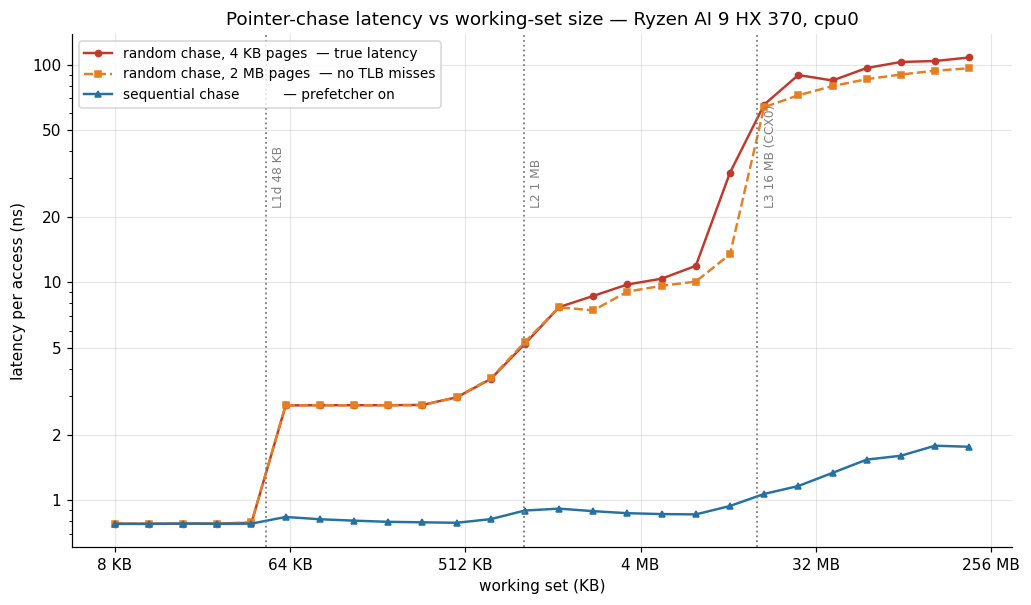

In [3]:
fig, ax = plt.subplots(figsize=(9.5, 5.6))

styles = [("random", "random chase, 4 KB pages  — true latency", "o-",  "#c0392b"),
          ("huge",   "random chase, 2 MB pages  — no TLB misses", "s--", "#e67e22"),
          ("seq",    "sequential chase          — prefetcher on", "^-",  "#2471a3")]
for mode, label, style, color in styles:
    xs = [int(r["bytes"]) / 1024 for r in lat if r["mode"] == mode]
    ys = [float(r["ns"])         for r in lat if r["mode"] == mode]
    ax.plot(xs, ys, style, color=color, label=label, ms=4, lw=1.6)

# the capacities the hardware actually has, from §2
for kb, name in [(48, "L1d 48 KB"), (1024, "L2 1 MB"), (16 * 1024, "L3 16 MB (CCX0)")]:
    ax.axvline(kb, color="gray", ls=":", lw=1.2)
    ax.text(kb * 1.08, 22, name, rotation=90, fontsize=8, color="gray", va="bottom")

ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xlabel("working set (KB)"); ax.set_ylabel("latency per access (ns)")
ax.set_title("Pointer-chase latency vs working-set size — Ryzen AI 9 HX 370, cpu0")
ax.set_xticks([8, 64, 512, 4096, 32768, 262144])
ax.set_xticklabels(["8 KB", "64 KB", "512 KB", "4 MB", "32 MB", "256 MB"])
ax.set_yticks([1, 2, 5, 10, 20, 50, 100]); ax.set_yticklabels([str(v) for v in [1,2,5,10,20,50,100]])
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

In [4]:
# The plateaus, read off at a size that sits safely inside each level.
levels = [("L1d",  32 << 10,   "48 KB, 12-way, private to a core"),
          ("L2",   256 << 10,  "1 MB, 16-way, private to a core"),
          ("L3",   8 << 20,    "16 MB on CCX0, shared by 4 cores"),
          ("DRAM", 128 << 20,  "LPDDR5X, shared by everything")]

print(f"{'level':<6}{'working set':>13}{'ns':>8}{'cycles':>9}{'x L1':>7}   {'what it is'}")
l1_ns = float(at("random", 32 << 10)["ns"])
for name, size, what in levels:
    r = at("random", size)
    ns, cyc = float(r["ns"]), float(r["cycles"])
    print(f"{name:<6}{int(r['bytes'])/1024:>10.0f} KB{ns:>8.2f}{cyc:>9.0f}{ns/l1_ns:>7.0f}   {what}")

lat_ssd = store["random_4k_read_latency"][0] * 1000       # us -> ns
print(f"{'NVMe':<6}{'(4 KB read)':>13}{lat_ssd:>8.0f}{lat_ssd*5.07:>9.0f}{lat_ssd/l1_ns:>7.0f}"
      f"   Crucial P310, O_DIRECT, queue depth 1")

level   working set      ns   cycles   x L1   what it is
L1d           27 KB    0.78        4      1   48 KB, 12-way, private to a core
L2           308 KB    2.74       14      4   1 MB, 16-way, private to a core
L3          7882 KB   11.91       60     15   16 MB on CCX0, shared by 4 cores
DRAM      134673 KB  103.88      523    133   LPDDR5X, shared by everything
NVMe    (4 KB read)   45800   232206  58793   Crucial P310, O_DIRECT, queue depth 1


### Reading the plot

The curve is a **staircase**, and each tread is a level of the hierarchy. The step happens exactly
where the working set outgrows a capacity reported by `/sys` in §2 — which is the point: this is not
a model, it is the hardware being visible.

* **Up to 48 KB — 4 cycles.** Everything is in L1d. This is the fastest a load can possibly be.
* **48 KB to 1 MB — 14 cycles.** L2. Already 3.5x, and note that *nothing in your source code
  changed* to make it so.
* **1 MB to 16 MB — 27 to 60 cycles.** L3, and unlike L1 and L2 it is not flat: L3 is physically
  distributed in slices, so latency grows with how much of it you are using.
* **Past 16 MB — about 530 cycles, ≈105 ns.** DRAM. The step at 16 MB is the CCX0 L3 running out.
  A thread on cpu4–11 would take this step at 8 MB instead.

**The headline number: DRAM costs 133 L1 accesses.** In the time one DRAM load takes, this core
could have retired roughly 500 instructions. That ratio is the *memory wall*, and it is the reason
the rest of this notebook exists: core throughput has grown for decades while DRAM latency has
barely moved, so the amount of work a core forgoes while waiting on memory keeps climbing. You
cannot make the wait shorter. You can only arrange not to wait.

---
## 4. What the prefetcher does, and what it cannot do

The blue curve is the same chase with the lines in address order instead of random order. It is
nearly **flat**: 4 cycles in L1, 9 cycles at 256 MB. The hardware watched a few accesses, inferred
the pattern, and issued the loads far enough ahead that the data arrived before it was asked for.

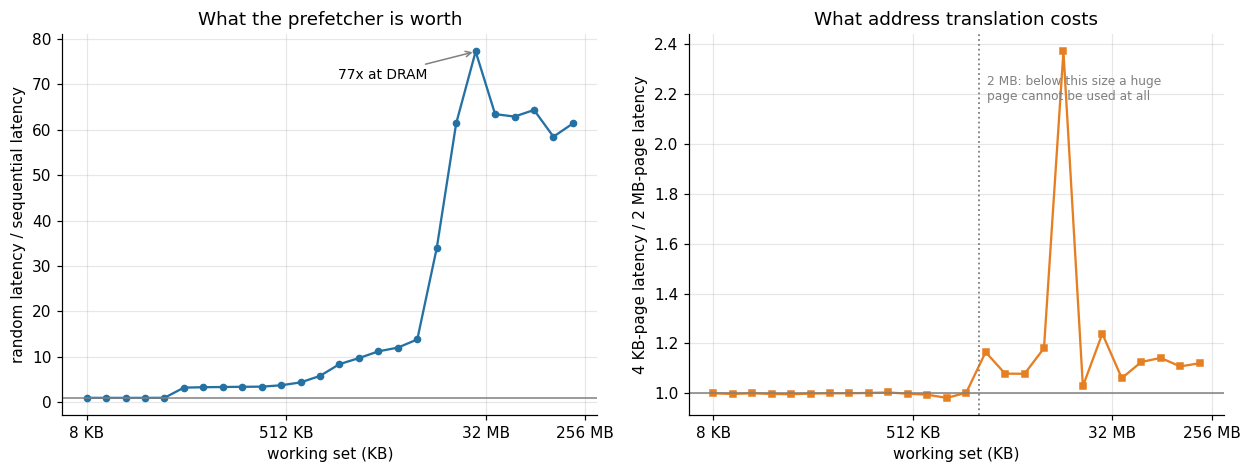

128 MB (DRAM)      random 4K-page   103.9 ns | sequential   1.78 ns | random 2M-page    93.8 ns
12 MB (inside L3)  random 4K-page    31.9 ns | sequential   0.94 ns | random 2M-page    13.5 ns


In [5]:
sizes = sorted({int(r["bytes"]) for r in lat})
by = {(r["mode"], int(r["bytes"])): float(r["ns"]) for r in lat}

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

ax = axes[0]
ratio = [by[("random", s)] / by[("seq", s)] for s in sizes]
ax.plot([s/1024 for s in sizes], ratio, "o-", color="#2471a3", ms=4)
ax.axhline(1, color="gray", lw=1)
ax.set_xscale("log", base=2); ax.set_xlabel("working set (KB)")
ax.set_ylabel("random latency / sequential latency")
ax.set_title("What the prefetcher is worth")
ax.set_xticks([8, 512, 32768, 262144]); ax.set_xticklabels(["8 KB", "512 KB", "32 MB", "256 MB"])
ax.annotate(f"{max(ratio):.0f}x at DRAM", xy=(sizes[ratio.index(max(ratio))]/1024, max(ratio)),
            xytext=(-90, -18), textcoords="offset points", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="gray"))

ax = axes[1]
tlb = [by[("random", s)] / by[("huge", s)] for s in sizes]
ax.plot([s/1024 for s in sizes], tlb, "s-", color="#e67e22", ms=4)
ax.axhline(1, color="gray", lw=1)
ax.axvline(2048, color="gray", ls=":", lw=1.2)
ax.text(2400, max(tlb) * 0.96, "2 MB: below this size a huge\npage cannot be used at all",
        fontsize=8, color="gray", va="top")
ax.set_xscale("log", base=2); ax.set_xlabel("working set (KB)")
ax.set_ylabel("4 KB-page latency / 2 MB-page latency")
ax.set_title("What address translation costs")
ax.set_xticks([8, 512, 32768, 262144]); ax.set_xticklabels(["8 KB", "512 KB", "32 MB", "256 MB"])

plt.tight_layout(); plt.show()

for label, target in [("128 MB (DRAM)", 128 << 20), ("12 MB (inside L3)", 12 << 20)]:
    b = int(at("random", target)["bytes"])
    print(f"{label:<18} random 4K-page {by[('random', b)]:7.1f} ns | "
          f"sequential {by[('seq', b)]:6.2f} ns | random 2M-page {by[('huge', b)]:7.1f} ns")

The prefetcher is worth up to **77x** at DRAM sizes (61x at the largest size measured). That is the single largest performance factor
in this notebook, and you get it for free — *if* your access pattern is predictable.

It is worth being precise about what "predictable" means, because it is the practical content of
"write sequential code":

| pattern | prefetched? |
|---|---|
| `a[i]`, `a[i+1]`, … | yes, trivially |
| constant stride, forward or backward | yes |
| several interleaved constant-stride streams | yes, up to a limited number of streams |
| pointer chasing a linked list or tree | **no** — the address is not known until the load returns |
| hash table probes | **no** |
| indirect / gather, `a[idx[i]]` | **no** |
| anything crossing a page boundary unpredictably | prefetchers do not cross pages speculatively |

The bottom four rows are why linked lists, `std::map`, and hash tables lose to flat arrays far more
often than their asymptotic complexity suggests: a `O(log n)` tree walk of 20 dependent DRAM
accesses costs 2 microseconds, while scanning 10,000 contiguous elements costs less.

When your pattern is irregular but *known in advance*, you can prefetch by hand with
`__builtin_prefetch` — see [`../prefetch.example/`](../prefetch.example/prefetch.md) in this repo
for a worked gather example.

---
## 5. The TLB: the cache nobody mentions

Address translation gets its own section because it is a **second complete cache hierarchy sitting
in front of the first one**, with its own capacities and its own cliff — and because it appears in
none of the caches enumerated in §2, so nothing you read from `/sys` will warn you about it.

Every memory access your program makes uses a **virtual** address that hardware must translate to a
**physical** one, by walking a four-level page table — which is itself in memory. If that walk went
to DRAM every time, every load would cost four DRAM accesses. So translations are cached in the
**TLB** (translation lookaside buffer), and a Zen 5 core has an L1 DTLB of 96 entries and an L2 TLB
of a few thousand.

With standard 4 KB pages, 96 entries covers **384 KB**. Past that, some fraction of your loads pay
for a page walk on top of the cache access. The orange curve above is the same random chase on 2 MB
huge pages, where 96 entries covers 192 MB and the TLB effectively disappears:

* **below 2 MB** the curves are identical — a huge page cannot back a region smaller than itself
* **at a 12 MB working set** — data that *fits in L3* — 4 KB pages cost 32 ns and 2 MB pages cost
  13 ns. **A 2.4x difference on identical data in an identical cache.** The extra time is not cache
  misses; it is page walks
* **at DRAM sizes** huge pages are worth a steady 10%

This is why databases, JVMs, and HPC runtimes all ask for huge pages. On Linux you get them with
`madvise(ptr, len, MADV_HUGEPAGE)` on a 2 MB-aligned allocation, which is exactly what
`cache_latency.c` does — and it then verifies through `/proc/self/smaps` that the kernel actually
granted them, because `MADV_HUGEPAGE` is a request, not a promise.

---
## 6. The cache line is the unit of everything

Nothing in the memory system moves one byte. **The cache line is the quantum of transfer**, and on
this machine — on all x86 — it is **64 bytes** at every level (`coherency_line_size` in §2 says so).

> 64 is the number to memorize for x86; Apple's M-series uses 128-byte lines. The distinction is not
> trivia — it is the constant you pad to when you fix false sharing (§9) and the one you divide by
> when you reason about wasted bandwidth. Padding tuned for the wrong one is either half wasted or
> half broken. Read it from `coherency_line_size` rather than hardcoding it.

The consequence is the most useful mental model in this notebook: **the memory system is a
vectorized parallel machine**. Every access loads 64 bytes in parallel. Using one byte of them costs
the same as using all 64. So the question to ask about a loop is not "how many bytes do I need?" but
**"of every 64 bytes I force the hardware to move, how many do I use?"**

The stride sweep answers it directly. We read one 8-byte word every `stride` bytes from a 128 MB
array and plot two curves: bytes we *asked for* per second, and bytes the hardware actually *moved*
per second.

Source: [`stride_bandwidth.c`](stride_bandwidth.c)

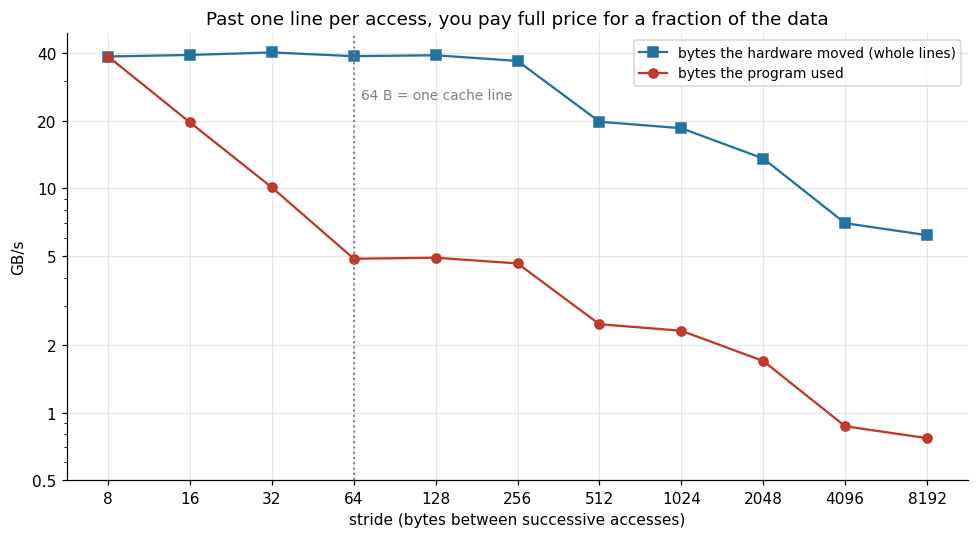

  stride  ns/access  useful GB/s  moved GB/s   line utilization
       8       0.21        38.76       38.76    12.5% of each line used
      16       0.41        19.69       39.38    25.0% of each line used
      32       0.79        10.10       40.41    50.0% of each line used
      64       1.65         4.86       38.90   100.0% of each line used
     128       1.63         4.91       39.26   100.0% of each line used
     256       1.73         4.63       37.03   100.0% of each line used
     512       3.23         2.48       19.84   100.0% of each line used
    1024       3.45         2.32       18.56   100.0% of each line used
    2048       4.71         1.70       13.60   100.0% of each line used
    4096       9.15         0.87        7.00   100.0% of each line used
    8192      10.33         0.77        6.19   100.0% of each line used


In [6]:
xs      = [int(r[1]) for r in stride]
useful  = [float(r[3]) for r in stride]
fetched = [float(r[4]) for r in stride]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(xs, fetched, "s-", color="#2471a3", label="bytes the hardware moved (whole lines)")
ax.plot(xs, useful,  "o-", color="#c0392b", label="bytes the program used")
ax.axvline(64, color="gray", ls=":", lw=1.3)
ax.text(68, 25, "64 B = one cache line", fontsize=9, color="gray")
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xlabel("stride (bytes between successive accesses)")
ax.set_ylabel("GB/s")
ax.set_title("Past one line per access, you pay full price for a fraction of the data")
ax.set_xticks(xs); ax.set_xticklabels([str(x) for x in xs])
ax.set_yticks([0.5, 1, 2, 5, 10, 20, 40]); ax.set_yticklabels(["0.5","1","2","5","10","20","40"])
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"{'stride':>8}{'ns/access':>11}{'useful GB/s':>13}{'moved GB/s':>12}   line utilization")
for r in stride:
    s, ns, u, f = int(r[1]), float(r[2]), float(r[3]), float(r[4])
    print(f"{s:>8}{ns:>11.2f}{u:>13.2f}{f:>12.2f}   {min(s,64)/64*100:>5.1f}% of each line used")

Between a stride of 8 and a stride of 64 the *fetched* bandwidth is a flat 39 GB/s — the memory
system is doing the same amount of work throughout. The *useful* bandwidth falls from 39 GB/s to
4.9 GB/s, an **8x loss**, and that factor of 8 is just $64 / 8$: one useful word per 64-byte line.

Past 64 bytes even the fetched curve collapses, because the prefetcher gives up on the pattern and
each access becomes an independent DRAM round trip.

This is the precise, quantitative version of the rule of thumb. Good memory access patterns are:

* **sequential** — consecutive addresses, so every byte of every line is used
* **aligned** — ranges starting on line boundaries, so you do not pull in a 65th byte and force a
  second line for one element
* **coalesced** — few large accesses rather than many small ones

and "sequential access is parallel access" means literally that: a stride-1 loop is using the
64-byte-wide hardware at full width.

---
## 7. Latency is not bandwidth

A level of the hierarchy is not one number, it is two, and they behave differently:

* **Latency** — how long *one dependent* access takes. That is §3, and it is what hurts when the
  next address depends on the last one (pointer chasing, tree walks, hash probes).
* **Bandwidth** — how much *independent* traffic a level sustains. That is what hurts when you are
  streaming over an array, where the accesses do not depend on each other and the hardware can keep
  dozens in flight.

They give different answers about the same hardware.

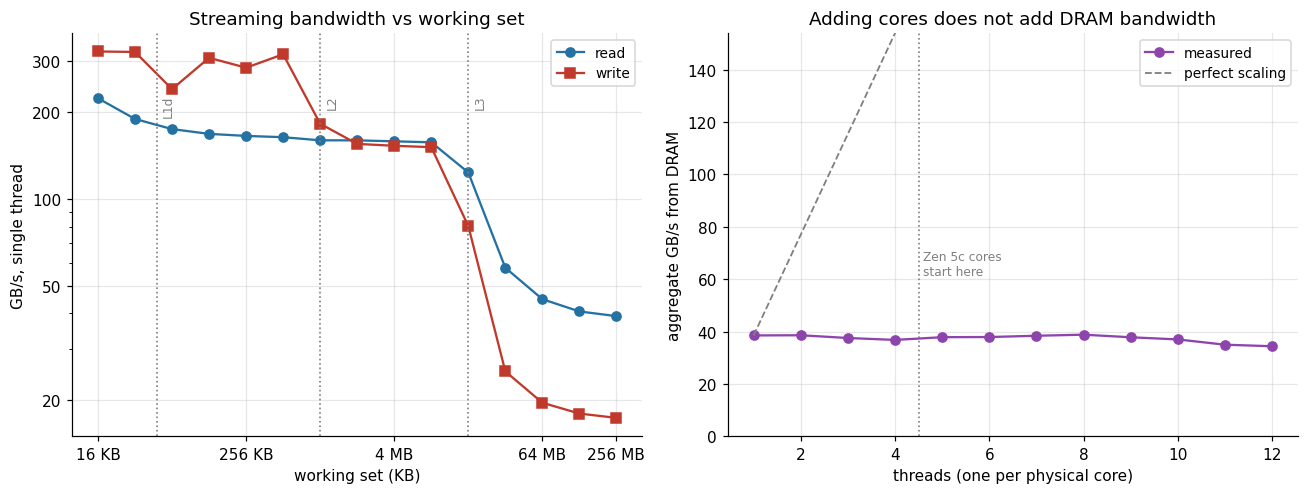

single-thread DRAM read : 38.5 GB/s
twelve-thread DRAM read : 38.8 GB/s   (1.01x for 12x the cores)
L1 read bandwidth       : 223 GB/s  (5.8x DRAM)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

ax = axes[0]
kb = [int(r[1]) / 1024 for r in bw]
ax.plot(kb, [float(r[2]) for r in bw], "o-", color="#2471a3", label="read")
ax.plot(kb, [float(r[3]) for r in bw], "s-", color="#c0392b", label="write")
for k, name in [(48, "L1d"), (1024, "L2"), (16*1024, "L3")]:
    ax.axvline(k, color="gray", ls=":", lw=1.1)
    ax.text(k*1.1, 230, name, fontsize=8, color="gray", rotation=90, va="top")
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xlabel("working set (KB)"); ax.set_ylabel("GB/s, single thread")
ax.set_title("Streaming bandwidth vs working set")
ax.set_xticks([16, 256, 4096, 65536, 262144])
ax.set_xticklabels(["16 KB", "256 KB", "4 MB", "64 MB", "256 MB"])
ax.set_yticks([20, 50, 100, 200, 300]); ax.set_yticklabels(["20","50","100","200","300"])
ax.legend(fontsize=9)

ax = axes[1]
th  = [int(r["threads"]) for r in scale]
gbs = [float(r["read_GBps"]) for r in scale]
ax.plot(th, gbs, "o-", color="#8e44ad", label="measured")
ax.plot(th, [gbs[0] * t for t in th], "--", color="gray", lw=1.2, label="perfect scaling")
ax.axvline(4.5, color="gray", ls=":", lw=1.1)
ax.text(4.6, gbs[0]*1.6, "Zen 5c cores\nstart here", fontsize=8, color="gray")
ax.set_ylim(0, gbs[0] * 4)
ax.set_xlabel("threads (one per physical core)"); ax.set_ylabel("aggregate GB/s from DRAM")
ax.set_title("Adding cores does not add DRAM bandwidth")
ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

print(f"single-thread DRAM read : {gbs[0]:.1f} GB/s")
print(f"twelve-thread DRAM read : {max(gbs):.1f} GB/s   ({max(gbs)/gbs[0]:.2f}x for 12x the cores)")
print(f"L1 read bandwidth       : {float(bw[0][2]):.0f} GB/s  ({float(bw[0][2])/gbs[0]:.1f}x DRAM)")

Two results here, and the second one is the important one.

**Bandwidth falls off a hierarchy just like latency does** — 223 GB/s out of L1, ~160 GB/s out of
L2 and L3, 39 GB/s from DRAM. Writes are faster than reads inside the caches and *slower* to DRAM
(a write to DRAM usually costs a read too: the line must be fetched before it can be modified).

**One core already saturates this machine's DRAM.** A single thread reads 38.5 GB/s; twelve threads
across both complexes read 38.8 GB/s. Twelve times the cores, 1.01x the bandwidth. That number
should reset your expectations for parallelizing anything memory-bound:

* A memory-bound loop gets **no speedup at all** from more cores here. Not a poor speedup — none.
  Amdahl's law is not the binding constraint; the memory controller is.
* Parallelism pays only when the extra threads bring extra *cache* with them (each core has its own
  L1 and L2), or when the work is compute-bound.
* This is precisely the ceiling a **roofline model** draws as its horizontal line. Everything to the
  left of the ridge point is stuck at 38 GB/s no matter how many cores you throw at it. See
  [`../roofline/`](../roofline/) for that framing, and note that measuring the ceiling — as we just
  did — is the first step in building one.

The figure to carry around is the machine's **balance**. A Zen 5 core retires two 512-bit FMAs per
cycle — $2 \times 8$ doubles $\times$ 2 flops = 32 flops/cycle, or 162 GFLOP/s at 5.07 GHz — while
DRAM delivers 38.5 GB/s, which is 4.8 billion doubles per second. That is

$$\frac{162 \text{ GFLOP/s}}{4.8 \text{ Gdouble/s}} \approx 34 \text{ flops per double loaded}$$

**If your loop does fewer than ~34 flops per element it reads from DRAM, it is not a computation; it
is a memory system with some arithmetic attached.** Dot products, `saxpy`, most of NumPy elementwise,
and every graph traversal live far below that line. Dense matrix multiply is one of the few common
kernels above it — which is exactly why it is the example everyone tiles.

---
## 8. Access patterns: row versus column, and a trap

The classic experiment. The same $N \times N$ writes, in the two possible nested-loop orders:

```c
for (x = 0; x < n; x++)          for (y = 0; y < n; y++)
    for (y = 0; y < n; y++)          for (x = 0; x < n; x++)
        a[x*lda + y] = 1.0;              a[x*lda + y] = 1.0;

     row order: stride 8 B                column order: stride lda*8 B
```

Cache-line granularity predicts a factor of 8 — a 64-byte line holds 8 doubles, and column order
uses one of them per fetch (§6). The measurement says up to **63x**. The extra factor comes from
**associativity** — the cache property that most treatments wave off as an implementation detail.

L1d here has **64 sets** and picks the set from address bits 6–11. When the row length is a power of
two, a column stride of `lda*8` bytes advances the set index by a fixed power-of-two amount, so an
entire column lands in a handful of sets and evicts itself — in a cache with plenty of unused room.
So each size is run twice: packed (`lda = n`) and padded by one element (`lda = n+1`), which makes
the stride odd in units of lines and spreads a column across every set.

Source: [`row_column.c`](row_column.c)

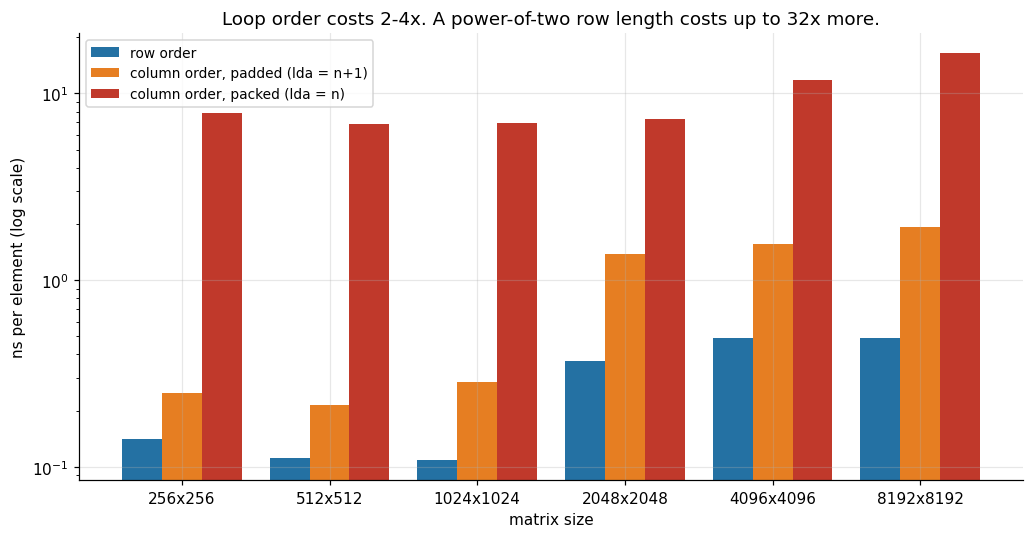

     N      row  col padded  col packed    order costs  pow2 costs     both
   256    0.141       0.248       7.822           1.8x       31.5x      55x
   512    0.111       0.215       6.845           1.9x       31.8x      62x
  1024    0.109       0.285       6.939           2.6x       24.3x      64x
  2048    0.370       1.389       7.289           3.8x        5.2x      20x
  4096    0.489       1.569      11.833           3.2x        7.5x      24x
  8192    0.489       1.923      16.367           3.9x        8.5x      33x


In [8]:
ns   = sorted({int(r["n"]) for r in rowcol})
pack = {int(r["n"]): r for r in rowcol if int(r["lda"]) == int(r["n"])}
pad  = {int(r["n"]): r for r in rowcol if int(r["lda"]) != int(r["n"])}

fig, ax = plt.subplots(figsize=(9.5, 5))
w, idx = 0.27, np.arange(len(ns))
ax.bar(idx - w, [float(pack[n]["row_ns"]) for n in ns], w, label="row order", color="#2471a3")
ax.bar(idx,     [float(pad[n]["col_ns"]) for n in ns],  w, label="column order, padded (lda = n+1)", color="#e67e22")
ax.bar(idx + w, [float(pack[n]["col_ns"]) for n in ns], w, label="column order, packed (lda = n)",  color="#c0392b")
ax.set_yscale("log")
ax.set_xticks(idx); ax.set_xticklabels([f"{n}x{n}" for n in ns])
ax.set_xlabel("matrix size"); ax.set_ylabel("ns per element (log scale)")
ax.set_title("Loop order costs 2-4x. A power-of-two row length costs up to 32x more.")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"{'N':>6}{'row':>9}{'col padded':>12}{'col packed':>12}   "
      f"{'order costs':>12}{'pow2 costs':>12}{'both':>9}")
for n in ns:
    r, cp, ck = float(pack[n]["row_ns"]), float(pad[n]["col_ns"]), float(pack[n]["col_ns"])
    print(f"{n:>6}{r:>9.3f}{cp:>12.3f}{ck:>12.3f}   "
          f"{cp/r:>11.1f}x{ck/cp:>11.1f}x{ck/r:>8.0f}x")

Read the last two columns:

* **"order costs" (1.8–3.9x)** is the honest price of walking a matrix the wrong way once the layout is
  benign. It is below the naive 8x prediction because the prefetcher recovers some of it — a
  constant stride is still a pattern, even a bad one.
* **"pow2 costs" (5–32x)** is the price of the *dimension being a power of two*, on top of the loop
  order. At $1024 \times 1024$, column order takes 6.94 ns per element packed and 0.29 ns padded:
  **adding 8 bytes per row makes the same loop 24x faster.** The effect is largest when the matrix
  would otherwise have fit comfortably in cache (256–1024), because there the conflict misses are
  pure waste; past 2048 the array misses to DRAM anyway and the layout matters less.

That second effect is worth internalizing, because power-of-two dimensions are exactly what people
choose: image tiles, FFT sizes, matrix benchmarks, texture atlases. The repo's own tiling
experiment ran into it independently — see the set-conflict discussion in
[`../loop_optimizations/loop_tiling.md`](../loop_optimizations/loop_tiling.md).

The fix is one of:

* **pad the leading dimension** to something odd (or odd multiples of the line size)
* **change the loop order** so the fast index is the contiguous one —
  [`../loop_optimizations/loop_interchange.md`](../loop_optimizations/loop_interchange.md)
* **tile the iteration space** so a block's working set fits in L1 or L2 —
  [`../loop_optimizations/loop_tiling.md`](../loop_optimizations/loop_tiling.md)

### Which index is contiguous?

Row-major (C, C++, NumPy default, Rust): the **last** index varies fastest, so `a[i][j]` wants `j`
inside. Column-major (Fortran, R, MATLAB, Julia, and most BLAS interfaces): the **first** index
varies fastest, so `a[i,j]` wants `i` inside. NumPy will hand you either — a transpose or a slice
produces a view with strides that make the "obvious" loop the wrong one, and `np.ascontiguousarray`
is how you find out.

> **Exercise.** Write the nested loop over `ar[row][col]` in Python/NumPy that touches elements in
> memory order — then check yourself with `ar.strides` and `ar.flags`. Then do it for
> `ar.T`, and explain why the answer changed when no data moved.

---
## 9. Sharing costs: coherence between cores

Everything so far was one thread. The moment two threads touch the same cache line, a second cost
appears that has nothing to do with capacity.

Caches are kept coherent by a protocol (MESI and its variants). A line can be held **Modified** by
exactly one core at a time. When core A writes a line, every other core's copy is invalidated; when
core B then reads or writes it, the line must be transferred. The unit of that ownership is — again —
**the 64-byte line**, not the variable. Two threads writing to two adjacent `long long` counters are,
as far as the hardware is concerned, fighting over the same object. That is **false sharing**, and
the repo has a full treatment with a 19x measured effect in
[`../false_sharing/false_sharing_ryzen.md`](../false_sharing/false_sharing_ryzen.md).

Here we measure the underlying quantity instead: **how long one handoff of one line between two
specific cores takes.** Two pinned threads ping-pong a value on a shared line; half a round trip is
the number plotted. This is what a lock handoff, an atomic counter, a producer/consumer queue, or a
false-shared array element actually costs, per exchange.

Source: [`core_to_core.c`](core_to_core.c)

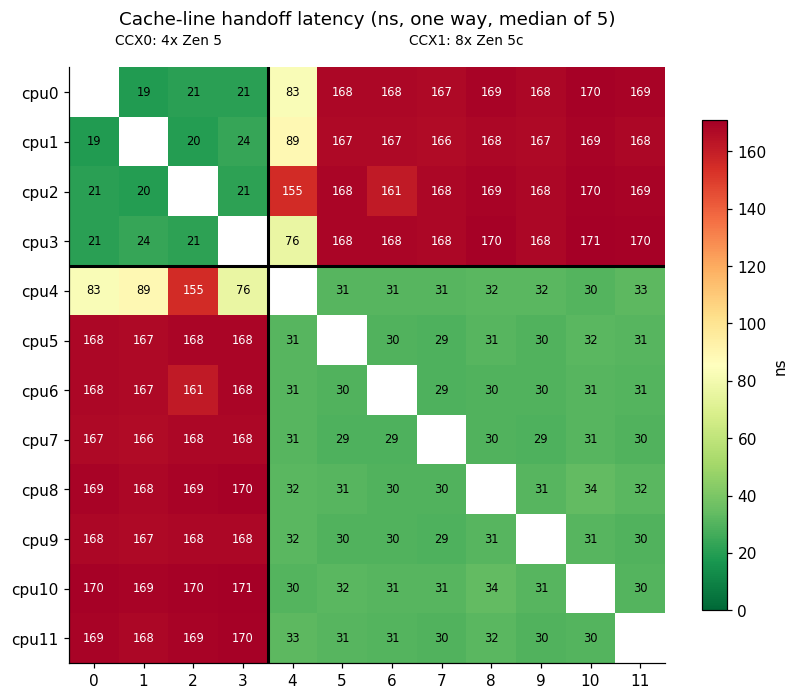

within CCX0 (Zen 5)      mean   20.9 ns   (range 19-24)
within CCX1 (Zen 5c)     mean   30.7 ns   (range 29-34)
across the complexes     mean  159.7 ns   (range 76-171)
SMT siblings (same core) cpu0/cpu12 18 ns, cpu4/cpu16 29 ns, cpu8/cpu20 28 ns

best case across complexes over all trials: 67 ns


In [9]:
N = 12
med = np.full((N, N), np.nan)
mn  = np.full((N, N), np.nan)
smt = []
for r in c2c:
    a, b = int(r["cpu_a"]), int(r["cpu_b"])
    if a < N and b < N:
        med[a, b] = med[b, a] = float(r["ns_median"])
        mn[a, b]  = mn[b, a]  = float(r["ns_min"])
    else:
        smt.append((a, b, float(r["ns_median"])))

fig, ax = plt.subplots(figsize=(7.6, 6.4))
im = ax.imshow(med, cmap="RdYlGn_r", vmin=0)
for i in range(N):
    for j in range(N):
        if not np.isnan(med[i, j]):
            ax.text(j, i, f"{med[i,j]:.0f}", ha="center", va="center", fontsize=7.5,
                    color="black" if med[i, j] < 120 else "white")
ax.set_xticks(range(N)); ax.set_yticks(range(N))
ax.set_xticklabels([f"{c}" for c in range(N)]); ax.set_yticklabels([f"cpu{c}" for c in range(N)])
ax.set_title("Cache-line handoff latency (ns, one way, median of 5)", pad=28)
for pos in (3.5,):
    ax.axhline(pos, color="black", lw=2); ax.axvline(pos, color="black", lw=2)
ax.text(1.5, -0.95, "CCX0: 4x Zen 5", ha="center", fontsize=9)
ax.text(7.5, -0.95, "CCX1: 8x Zen 5c", ha="center", fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.8, label="ns")
ax.grid(False)
plt.tight_layout(); plt.show()

def block(rows, cols):
    v = [med[i, j] for i in rows for j in cols if i != j and not np.isnan(med[i, j])]
    return np.mean(v), np.min(v), np.max(v)

ccx0, ccx1 = range(0, 4), range(4, 12)
for label, rows, cols in [("within CCX0 (Zen 5)", ccx0, ccx0),
                          ("within CCX1 (Zen 5c)", ccx1, ccx1),
                          ("across the complexes", ccx0, ccx1)]:
    m, lo, hi = block(rows, cols)
    print(f"{label:<24} mean {m:6.1f} ns   (range {lo:.0f}-{hi:.0f})")
print(f"{'SMT siblings (same core)':<24} "
      + ", ".join(f"cpu{a}/cpu{b} {v:.0f} ns" for a, b, v in smt))
print(f"\nbest case across complexes over all trials: {np.nanmin(mn[0:4, 4:12]):.0f} ns")

### What the map says

* **Same core, two SMT threads: ~18 ns.** The line never leaves L1. Hyperthreads share a cache,
  which is why SMT siblings are the cheapest place to put two communicating threads — and the worst
  place to put two threads that each want the whole L1.
* **Within CCX0 (the four Zen 5 cores): ~20 ns.** The handoff resolves in the shared 16 MB L3.
* **Within CCX1 (the eight Zen 5c cores): ~30 ns.** Same mechanism, more cores on the slice and a
  lower clock.
* **Across the complexes: ~160 ns mean, 167 ns typical.** The line has to cross the Infinity Fabric. That is
  **8x** the intra-complex cost, and it is *more than a DRAM access* (§3: 105 ns). Two threads
  passing a cache line between complexes are slower than two threads that never talk and each miss
  to DRAM.

There is one more thing in the data worth saying out loud, because it is the kind of result people
quietly delete. The cross-complex numbers are **bimodal and unstable**: the same pair measures 70 ns
on one trial and 168 ns on the next, while intra-complex pairs repeat to within a few percent. On a
mobile part the fabric and the idle CCX are power-managed, so the cost of reaching across depends on
what the rest of the chip happened to be doing. `core_to_core.c` therefore reports min, median and
max rather than a single number. **Cross-complex sharing is not just slower — it is
unpredictable**, which is worse for a parallel program, because tail latency is what a barrier waits
for.

### What to do about it

* **Do not share cache lines you do not mean to share.** Pad per-thread state to 64 bytes, or give
  each thread a local accumulator and combine once at the end. The repo measures both fixes:
  [`../false_sharing/`](../false_sharing/false_sharing_ryzen.md).
* **Place communicating threads near each other.** On this chip, `OMP_PLACES=cores` with
  `OMP_PROC_BIND=close` keeps a team inside one complex; `spread` deliberately does not. For 4
  threads or fewer, cpus 0–3 are both the fastest cores *and* the cheapest to synchronize.
* **Count handoffs, not just work.** A lock acquired 10 million times costs 1.7 seconds in coherence
  traffic alone if the threads are on opposite complexes, before any of your code runs.
* **Do not assume a topology.** The next machine has a different one. Read it from `/sys` (§2), or
  measure it with this benchmark.

---
## 10. The whole hierarchy, measured

Putting every measurement in this notebook on one scale. The "human time" column rescales the
latency column so that an L1 hit takes one second — the standard trick for making six orders of
magnitude legible.

In [10]:
GHZ = 5.07                                   # the boosted clock the runs held; see §3

l1  = float(at("random", 32 << 10)["ns"])
rows = [
    ("register",      1 / GHZ,               "1",     "~1 KB",  "private to a core"),
    ("L1d",           l1,                    f"{float(at('random',32<<10)['cycles']):.0f}",
                                             "48 KB",  "private to a core"),
    ("L2",            float(at("random", 256 << 10)["ns"]),
                                             f"{float(at('random',256<<10)['cycles']):.0f}",
                                             "1 MB",   "private to a core"),
    ("L3",            float(at("random", 8 << 20)["ns"]),
                                             f"{float(at('random',8<<20)['cycles']):.0f}",
                                             "16/8 MB", "shared within a complex"),
    ("DRAM",          float(at("random", 128 << 20)["ns"]),
                                             f"{float(at('random',128<<20)['cycles']):.0f}",
                                             "14 GB",  "shared by everything"),
    ("NVMe SSD",      store["random_4k_read_latency"][0] * 1000,
                                             f"{store['random_4k_read_latency'][0]*1000*GHZ:.0f}",
                                             "931 GB", "shared, and persistent"),
]

def human(seconds_ratio):
    s = seconds_ratio
    for unit, n in (("s", 1), ("min", 60), ("h", 3600), ("days", 86400)):
        if s < 60 * n or unit == "days":
            return f"{s/n:.1f} {unit}"

print(f"{'level':<10}{'latency':>11}{'cycles':>9}{'capacity':>10}  {'human time':<11}{'scope'}")
print("-" * 78)
for name, ns, cyc, cap, scope in rows:
    print(f"{name:<10}{ns:>9.2f} ns{cyc:>9}{cap:>10}  {human(ns/l1):<11}{scope}")

print()
print(f"sequential DRAM read bandwidth, 1 thread : {float(scale[0]['read_GBps']):.1f} GB/s")
print(f"sequential DRAM read bandwidth, 12 threads: {max(float(r['read_GBps']) for r in scale):.1f} GB/s")
print(f"NVMe sequential read bandwidth           : {store['sequential_read_bandwidth'][0]:.2f} GB/s")
print(f"span of the hierarchy                    : "
      f"{rows[-1][1]/l1:,.0f}x from L1 to SSD")

level         latency   cycles  capacity  human time scope
------------------------------------------------------------------------------
register       0.20 ns        1     ~1 KB  0.3 s      private to a core
L1d            0.78 ns        4     48 KB  1.0 s      private to a core
L2             2.74 ns       14      1 MB  3.5 s      private to a core
L3            11.91 ns       60   16/8 MB  15.3 s     shared within a complex
DRAM         103.88 ns      523     14 GB  2.2 min    shared by everything
NVMe SSD   45800.00 ns   232206    931 GB  16.3 h     shared, and persistent

sequential DRAM read bandwidth, 1 thread : 38.5 GB/s
sequential DRAM read bandwidth, 12 threads: 38.8 GB/s
NVMe sequential read bandwidth           : 2.95 GB/s
span of the hierarchy                    : 58,793x from L1 to SSD


The bottom two rows are where the familiar textbook picture of a memory hierarchy least resembles
this machine.

* **There is no persistent-memory tier**, and there is not one to buy: Intel discontinued Optane in
  2022. The idea survives in CXL-attached memory, which is a different technology with different
  numbers.
* **There is no rotating disk.** What sits below DRAM here is one NVMe SSD, at 45.8 µs and
  2.95 GB/s — roughly **450x DRAM's latency and 13x its bandwidth**.

That last ratio is worth pausing on. A 450x latency gap is enormous by the standards of everything
above it in the table, but it is small by the standards of the storage gap that most algorithm
design still assumes. "Does the dataset fit in memory?" was once the only question worth asking
about a large input, because the alternative was unthinkably slow. Here the alternative is 13x less
bandwidth — which is why memory-mapped files, `io_uring`, and out-of-core algorithms are reasonable
engineering rather than a last resort.

And read the human-time column once more. If an L1 hit takes one second, L2 takes three and a half,
L3 fifteen, DRAM **more than two minutes**, and the SSD **two thirds of a day**. Those six rows are
the entire performance problem, and the checklist in §11 is really one instruction: stay as high in
that column as your data will let you.

---
## 11. What to actually do

In rough order of how much they are worth on this machine:

1. **Make the inner loop sequential.** Worth up to 77x through the prefetcher alone (§4). This is
   the whole game. Everything else on this list is a rounding error next to it.
2. **Use every byte of every line you touch.** Structure-of-arrays instead of array-of-structures
   when a loop reads one field of many records; 8x is sitting there (§6).
3. **Do not size arrays as powers of two** when you traverse them by column or tile them. Padding
   the leading dimension by one element is free and was worth up to 32x (§8).
4. **Give each thread its own cache lines.** Pad shared state to 64 bytes; accumulate locally and
   combine once (§9).
5. **Keep communicating threads in one complex**, and remember cores 5–12 of this chip are the slow
   ones (§2, §9).
6. **Ask for huge pages** for large working sets — one `madvise` call, worth 2.4x on an L3-resident
   random access pattern (§5).
7. **Prefetch by hand only when the pattern is irregular but known** — a gather with computed
   indices. The hardware already has the easy cases ([`../prefetch.example/`](../prefetch.example/prefetch.md)).
8. **Stop parallelizing memory-bound loops.** One core saturates DRAM here; twelve get 1% more (§7).
   Fix the access pattern first, then parallelize what is left.

And the meta-rule, which the measurement bugs in this notebook illustrate better than any advice
could: **measure on the machine you will run on.** The clock moves, the topology is not uniform, the
L3 you get depends on which core you land on, and the cross-complex latency depends on what the rest
of the chip is doing. Two of the benchmarks here had to be rewritten after their first run produced
confident, reproducible, wrong answers.

### Assigned reading

[How to optimize a CPU matrix multiplication kernel](https://siboehm.com/articles/22/Fast-MMM-on-CPU)
— siboehm. Still the best single walkthrough of turning a memory-bound kernel into a compute-bound
one, and it uses every idea in this notebook: tiling for L1/L2/L3, packing for line utilization,
and the arithmetic-intensity argument from §7.

### Where this connects in the repo

| Topic | Directory |
|---|---|
| Loop interchange, tiling, fusion, fission | [`../loop_optimizations/`](../loop_optimizations/README.md) |
| False sharing, measured at 19x | [`../false_sharing/`](../false_sharing/false_sharing_ryzen.md) |
| Software prefetching for gathers | [`../prefetch.example/`](../prefetch.example/prefetch.md) |
| Arithmetic intensity and the bandwidth ceiling | [`../roofline/`](../roofline/) |
| Vectorization, which multiplies the cost of a bad layout | [`../vectorization/`](../vectorization/README.md) |
| Sorting: the canonical cache-sensitive algorithm | [`../sorting/`](../sorting/intro.md) |

---
## 12. Reproducing this

Everything here is six small C programs and the `.csv` files they emit.

```bash
make          # build all six benchmarks
make data     # run them all, overwrite the .csv files (~12 min, needs an idle machine)
```

Then set `RUN_BENCHMARKS = True` in the setup cell, or just re-run the notebook against the
committed `.csv` files.

| program | measures | §|
|---|---|---|
| [`cache_latency.c`](cache_latency.c) | pointer-chase latency vs working set, 4 KB vs 2 MB pages | 3, 4, 5 |
| [`stride_bandwidth.c`](stride_bandwidth.c) | line utilization vs stride; bandwidth vs working set | 6, 7 |
| [`bandwidth_scaling.c`](bandwidth_scaling.c) | aggregate DRAM bandwidth vs thread count | 7 |
| [`row_column.c`](row_column.c) | nested-loop order and the power-of-two set conflict | 8 |
| [`core_to_core.c`](core_to_core.c) | cache-line handoff latency for every core pair | 9 |
| [`storage_latency.c`](storage_latency.c) | NVMe random-read latency and sequential bandwidth | 10 |
| [`spin_cost.c`](spin_cost.c) | what a PAUSE spin loop costs, per core type | &mdash; |
| [`set_conflict.c`](set_conflict.c) | traversal time against L1 sets reachable | &mdash; |
| [`tlb_walk.c`](tlb_walk.c) | TLB capacity, by touching many pages and little data | 5 |

Each `.c` file opens with a comment explaining what it measures and, more usefully, which
measurement traps it had to avoid. Those comments are the part worth reading before you write your
own benchmark: pinning, clock calibration, defeating the prefetcher on purpose, multiple
accumulators, aggregating a parallel run over the slowest thread rather than the sum of rates.

### Two diagrams

Two standalone pages in this directory cover the same ground visually, and open in a browser with
no server:

* [`cache_map.html`](cache_map.html) &mdash; the floorplan with L3 drawn to capacity, the latency
  ladder, the coherence map, and a decomposition of why a cache-line handoff costs far more than a
  cache hit.
* [`why_1024_is_slow.html`](why_1024_is_slow.html) &mdash; the address arithmetic behind &sect;8's
  power-of-two result, worked through one bit at a time.
* [`tlb_cliff.html`](tlb_cliff.html) &mdash; address translation, where the L1 DTLB's 96 entries
  run out, and why huge pages fix &sect;5's result.

### Exercises

1. **Find the other L3.** Every single-threaded benchmark here pins to cpu0. Re-run
   `./cache_latency 6` and explain where the DRAM step moves to, and why.
2. **Break the prefetcher gradually.** Modify `cache_latency.c` to chase a chain that is random
   within a 4 KB block but sequential between blocks. Where does the curve land relative to the
   fully-random and fully-sequential ones, and what does that tell you about how far ahead the
   prefetcher works?
3. **Predict, then measure.** Before running `./row_column`, predict the packed/padded ratio for
   $N = 1023$ and $N = 1024$. Explain any surprise with the set-index arithmetic from §8.
4. **Cost a lock.** Using the §9 numbers, estimate the coherence cost of an OpenMP `reduction` over
   12 threads, versus the same reduction with per-thread accumulators. Then check your estimate
   against [`../openmp/prefix_sum.md`](../openmp/prefix_sum.md).